<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/Decision_Fusion_for_APT_Detection_20250509.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Decision Fusion For Cyber-Physical Threat Detection

**The purpose of decision fusion is to provide a holistic view on detecting Advanced Persistent Threats (APT) attack behaviours that leverages Living off the Land (LOTL) technqiues to induce cyber-physical attacks in industrial settings.**

**This notebook demonstrates the process of creating a Two-Level Decision Fusion for detecting a multi-stage attack simulated on a Digital Twin-based testbed on 9 May 2025. During the simulation, Network, process and host data are collected and analysed for threat detection.**

#Objective of This Notebook

**The goal of this notebook is to show the process of decision fusion for cross-domain anomalies, including**

*   1st Level - OT fusion (OPC UA Network Anomaly + Process Anomaly + Process Alarm)
*   2nd Level - IT / OT fusion (the output of the OT fusion + Host Anomaly)


*Note: Separate notesbooks in the Github provides information about how the anomalies in cross-domain (host, network, process) are being processed and detected.*

#Background

A multi-stage cyber-physical attack simulation was conducted on 9 May 2025, between 14:34 and 17:02 (UK local time), using a Digital Twin-based testbed replicating a sorting process controlled within Siemens NX MCD. The testbed was integrated with HMI and OPC UA clients to simulate real-world adversarial behaviours targeting industrial actuators.

Out of the five attack steps, Step 3 and Step 5 involved manual manipulations of the physical process:

*   Step 3: Issued unauthorized commands through an HMI via RDP session.
*   Step 5: Executed unauthorized OPC UA write requests from UA Expert to the NX process.

These two steps are expected to exhibit anomalous actuator behaviours detectable in the process data and OPC UA network data.

In contrast, Steps 1, 2, and 4 involved activities confined to host and TCP/IP network layers (e.g., discovery, lateral movement) and thus do not influence the process state directly. For Step 1, 2 and 4, we simulated the use of Living off the Land techniques, including PowerShell-based reconnaissance, credential abuse, and lateral movement using native Windows binaries.

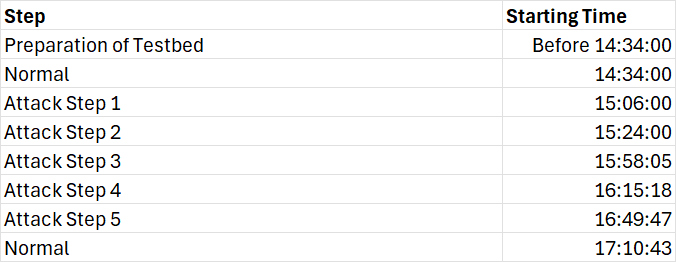

# Summary of the Anomaly Detection Models

**Different methods are used to detect anomalies considering the nature of the data and anomaly patterns as follows:**

### Detection Model for Network Anomaly (Unsupervised Machine Learning with Isolation Forest)

An unsupervised machine model using IsolaionForest from the sklearn libary is used for machine learning model development. The model focuses to detect if there is anomalous write commands issued in OPC UA network traffic in a specific minute.

To enhance the explainability of the abnormal write commands events via OPC UA clients, node_id captured by network traffic analyser are used in the model and could be extracted from decision logs to support incident investigation.

The trained model was used for inference on the attack simulated on 9 May 2025. The result indicates whether the process is:

*   Normal
*   Abnomal

For abnormal network cases, information about which OPC UA node_id could be shown for investigation.




### Detection Model for Process Anomaly (Supervised Deep Learnng wth LSTM-FCN)

A multivariate time series classification model using Long Short-Term Memory Fully Convolutional Networks (LSTM-FCN) from the sktime deep learning module is used for deep learning model development. The model focuses to detect if there is anomalous actuators behaviours in an automated sorting process.

To enhance explainability of the process anomaly, the model is trained with multiple high risk scenarios to produce datasets that could provide multi-class anomaly detection result. The result indicates whether the process in a specific minute is:
*   Label #0 - 'Normal_NoIntervention': Baseline operation without intervention.
*   Label #1 - 'Conveyor_SpeedManipulation':Speed forcibly reduced from standard (e.g., 300 to 50, or 50 to 10).
*   Label #2 - 'Gripper_SuctionForceRelease': Suction signal changed from 1 (hold) to 0 (release).
*   Label #3 - 'Gripper_ZAxisDirectionManipulation': Reverses Z-axis movement by forcing -400 (downward) instead of +400 (upward), and vice versa.
*   Label #4 - 'Gripper_RotationDeviation': Rotation angle forced to inappropriate value (e.g., 0° to 360°).
*   Label #5 - Multi-vector attacks of the above scenarios

The trained model was used for inference on the attack simulated on 9 May 2025.

Furthermore, the process alarms are also incorporated after the model inference to further enhance the visibility of process anomaly detection.

### Detection Model for Host Anomaly (Point-based Feature Scoring System)

The detection approach uses a binary rule-based feature scoring system, where selected host-level security events are assigned 1 point if triggered during a specific minute. These features are derived from Wazuh alerts and mapped to MITRE ATT&CK techniques relevant to host compromise, lateral movement using Living off the Land (LOTL) techniques.

Anomaly scores are then aggregated per minute, and each time window is further enriched with explanations of which security rules or behaviors were triggered. This enables:
*   Minute-level anomaly tracking
*   Monitor events captured by Windows and sysmon
*   Map to well-known real-world MITRE ATT&CK TTP ID to support incident handling
*   Provide clear rationale for alerts for situation awareness and human understandable explaination va support from LLM

It is important to note that the point-based features are customizable, as different industrial settings would have different attack surfaces and systems that require flexible detection rules. The rules used in this study is mainly used for detecting the attack simulated in the Digital Twin testbed, with the goal of validating the effectiveness of the community-driven detection rules on attack behaviours that leverage LOTL techniques.

Rather than a black-box model, the point-based feature enables operators and incident response team to quickly identify the instrusion with recognisable threats based on well-known MITRE ATT&ACK cyber threat intelligence.


# Overview of Decision Fusion

## **Alignment or Correlation Strategy for Decision Fusion**

The models are trained to detect anomalies aggregated per minute. Therefore, all anomalies from different modality could be aligned based on time (1-minute) and processed in batch instead of real-time.

The ratonale of accumulating anomaly in every minute for detection includes:
*   reduce the number of alarms comparing to real-time detection, minimising the issue of alert fatigue
*   magnify the intensity of the anomalies per minute to enable trend analysis, revealing ongoing multi-stage attack
*   minimise incomplete or inaccurate decision due to network latency issue which may happen for real-time analysis in distributed environment





## **1st Level Decision Fusion - OT Fusion**

The goal is to generate insights from multiple sources to enable a unified OT-level decision for operators to discover if the physical process anomaly is a cyber-attack or not.

This insight is important for cyber situation awareness and better respond if it is a security incident rather than mechanical incident such as cauesd by wear and tear.

The fusion of network anomalies and process anomalies detected on cyber-physical system could contradict with each other, thus the focus of this level of fusion is to manage contradicting result.

### Reason for fusion process anomalies with network anomalies

*   The reason is that the model analysing network data could detect if there is abnormal OPC UA write commands via HMI or other OPC UA clients. If there is no corresponding write commands, it is likely that the process behaves differently, due to other reasons such as wear and tear, electrical or mechanical fault.

*   Moreover, due to resources limitation or distributed nature of physical systems, there is a possibility that the process logs are not complete or delayed. With this reasons, fusing with the network anomalies could reduce the risk of missing process data during anomaly detection.

*   Most importantly, different detection model has different detection performance (e.g. comparatively higher false positives for unsupervised model), fusing the anomaly results from multiple data source allows for more accuracy threat detection.  

### Reason for fusion process anomalies with process alarms from data historian

*   Alarm management and warning system are usually incorporated in industrial settings for safety and compliance reason. The alarm could indicate abnormal activities in process which may be missed out by the trained model.

*   If there is threshold-based alarm incurred in system related to the process behaviours, it is more likely to detect the cause of process disruption.




## **2nd Level Decision Fusion - IT / OT Fusion**

The goal is to gain insights from a wider data source to enable a holistic view of multi-stage, stealthy attack across IT/OT domain. Such attack behaviours are typically carried out by APT in ICS/OT settings.

This insight is important for early detection of the APT threat behaviours, unvealing the potential cyber instrusion that usually happen before physical attack.

Unlike fusion of network anomalies and process anomalies detected on cyber-physical system, the host anomalies would not contradict with the 1st level fused decision. The foucs on the 2nd level fusion is to merge the information for explainable and actionable insights.

### Reason for fusion host anomalies with OT anomalies

*   The reason is that the model analysing purely IT data (e.g. abnormal behaviours in hosts) lack the visibility on OT systems such as cyber-physical systems that manage the physical process.

*   Without correlating the IT anomalies with OT anomalies, it is hard to detect physical attack originated from IT systems.

It is important to note that the current study mainly included host-based Intrusion Detection System (IDS). Network-based IDS (such as Suricata) and other system telemetry (e.g. CPU performance, memory, etc.) could be incorporated.

#1st Level Decision Fusion - OT Fusion

## Step 1: Loading the list of process anomalies and network anomalies


### Network Anomalies

In [4]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load Network Data with Anomaly Scores calculated by Isolation Forest
# df_network = pd.read_csv("instance_anomaly_summary.csv")
df_network = pd.read_csv("Network_anomaly_summary_09May.csv")


Saving Network_anomaly_summary_09May.csv to Network_anomaly_summary_09May (1).csv


In [12]:
# Rename columns
df_network = df_network.rename(columns={
    'anomaly_score_0.2': 'Network_Anomaly_Score',
    'anomaly_0.2': 'Network_Predicted_Label'
})

df_network['Network_Predicted_Label'] = df_network['Network_Anomaly_Score'].apply(lambda x: 1 if x < 0 else 0)
df_network['instance'] = df_network['instance'].astype(int)

In [17]:
# Classify 3-level network labels
def interpret_anomaly(score):
    if score < -0.01:
        return 'Network - Anomaly'
    elif score > 0.01:
        return 'Network - Normal'
    else:
        return 'Network - Marginal'

df_network['Network_Label_3Class'] = df_network['Network_Anomaly_Score'].apply(interpret_anomaly)

In [18]:
df_network.columns = df_network.columns.str.strip()

In [19]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,Network_Label_3Class
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,Network - Normal
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,Network - Normal
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,Network - Normal
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,Network - Anomaly
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,Network - Anomaly
...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,Network - Anomaly
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,Network - Anomaly
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,Network - Anomaly
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,Network - Anomaly


In [62]:
# Count occurrences of each class
df_network['Network_Label_3Class'].value_counts()


,count
Network_Label_3Class,
Network - Normal,98
Network - Anomaly,38
Network - Marginal,12


In [63]:
# Filter marginal cases
n_marginal_cases = df_network[df_network['Network_Label_3Class'] == 'Network - Marginal']

# Get instance numbers (assuming 'instance' column exists)
n_marginal_instance_numbers = n_marginal_cases['instance'].tolist()

# Show result
print("Network Marginal Instances:", n_marginal_instance_numbers)

Network Marginal Instances: [23, 30, 36, 40, 51, 53, 58, 60, 62, 67, 69, 91]


**From the network-only detection results, 12 out of 148 instances (8%) fell into a marginal zone, where the anomaly score is near zero. These ambiguous cases could not be confidently classified as either normal or anomalous. This justifies the integration of process-level data for decision fusion, as it provides complementary context to resolve uncertainty in marginal instances.**

In [47]:
uploaded = files.upload()

df_explain_network_anomaly = pd.read_csv("opcua_network_anomalies_09May.csv")


Saving opcua_network_anomalies_09May.csv to opcua_network_anomalies_09May (1).csv


In [48]:
df_explain_network_anomaly.columns = df_explain_network_anomaly.columns.str.strip()  # Strip any extra spaces
df_explain_network_anomaly['timestamp'] = pd.to_datetime(df_explain_network_anomaly['timestamp'], dayfirst=True)

In [50]:
df_network = df_network.merge(df_explain_network_anomaly[['instance', 'timestamp', 'timestamp_bst', 'node_ids_written', 'source_ports', 'message_sizes', 'explanation']], on='instance', how='left')

In [51]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,Network_Label_3Class,timestamp,timestamp_bst,node_ids_written,source_ports,message_sizes,explanation
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,Network - Normal,NaT,NaN,NaN,NaN,NaN,NaN
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,Network - Normal,NaT,NaN,NaN,NaN,NaN,NaN
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,Network - Normal,NaT,NaN,NaN,NaN,NaN,NaN
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,Network - Anomaly,2025-09-05 13:38:00,2025-05-09 14:38:00+01:00,-,"53373, 53218","253, 100, 204, 189, 1584",Unusual OPC UA write pattern detected
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,Network - Anomaly,2025-09-05 13:39:00,2025-05-09 14:39:00+01:00,-,"53373, 53218","253, 100, 204, 189, 255",Unusual OPC UA write pattern detected
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,Network - Anomaly,2025-09-05 15:58:00,2025-05-09 16:58:00+01:00,"-, MCDData.GetBox_signal, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 159",Unusual OPC UA write pattern detected
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,Network - Anomaly,2025-09-05 15:59:00,2025-05-09 16:59:00+01:00,"-, MCDData.RotatePosition, MCDData.Gripper_Z_S...","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,Network - Anomaly,2025-09-05 16:00:00,2025-05-09 17:00:00+01:00,"-, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,Network - Anomaly,2025-09-05 16:01:00,2025-05-09 17:01:00+01:00,-,"52131, 53373, 53218","85, 66, 253, 100, 204",Unusual OPC UA write pattern detected


In [41]:
# Define attack periods (UTC time)
attackviaHMI_start = pd.to_datetime('2025-05-09 14:58:00')
attackviaHMI_end   = pd.to_datetime('2025-05-09 15:08:00')
attackviaUA_start  = pd.to_datetime('2025-05-09 15:52:00')
attackviaUA_end    = pd.to_datetime('2025-05-09 16:02:00')

In [57]:
# Load network anomaly results
df_visual_network = df_network.copy()
df_visual_network['ts'] = pd.to_datetime(df_visual_network['timestamp_bst'], utc=True).dt.tz_convert('Europe/London')

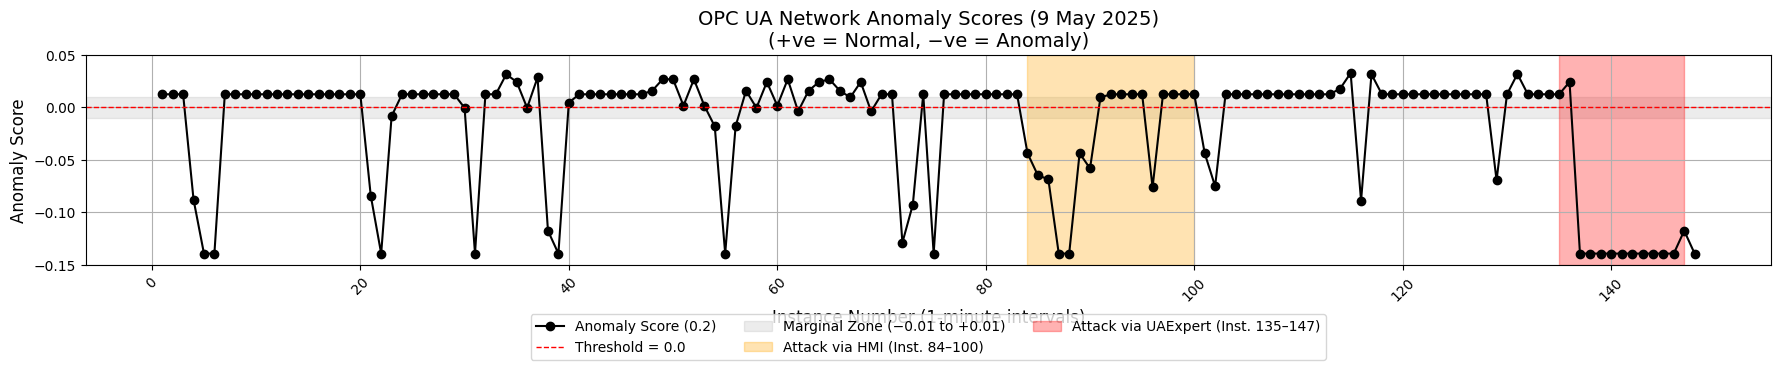

In [80]:
import matplotlib.pyplot as plt

# Define attack regions by instance range
attack_via_HMI = (84, 100)
attack_via_UAExpert = (135, 147)

# Create plot
plt.figure(figsize=(18, 4))
plt.plot(
    df_visual_network['instance'],
    df_visual_network['Network_Anomaly_Score'],
    marker='o', linestyle='-', color='black', linewidth=1.5,
    label='Anomaly Score (0.2)'
)

# Draw threshold and marginal band
plt.axhline(y=0.0, color='red', linestyle='--', linewidth=1, label='Threshold = 0.0')
plt.axhspan(-0.01, 0.01, color='gray', alpha=0.15, label='Marginal Zone (−0.01 to +0.01)')

# Highlight attack periods
plt.axvspan(attack_via_HMI[0], attack_via_HMI[1], color='orange', alpha=0.3, label='Attack via HMI (Inst. 84–100)')
plt.axvspan(attack_via_UAExpert[0], attack_via_UAExpert[1], color='red', alpha=0.3, label='Attack via UAExpert (Inst. 135–147)')

# Title and labels
plt.title("OPC UA Network Anomaly Scores (9 May 2025)\n(+ve = Normal, −ve = Anomaly)", fontsize=14)
plt.xlabel("Instance Number (1-minute intervals)", fontsize=12)
plt.ylabel("Anomaly Score", fontsize=12)

# Grid, axis range, ticks
plt.ylim(-0.15, 0.05)
plt.xticks(rotation=45)
plt.grid(True)

# Legend formatting
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=10)

# Layout adjustment
plt.tight_layout()
plt.show()

### Process Anomalies

In [64]:
uploaded = files.upload()

# Load Process Data with Class Scores calculated by LSTM-FCN
df_process = pd.read_csv("NX_predictions_09May_instances_with_alarms.csv")


Saving NX_predictions_09May_instances_with_alarms.csv to NX_predictions_09May_instances_with_alarms.csv


In [65]:
df_process.columns = df_process.columns.str.strip()


In [66]:
# Rename columns and reassign
df_process = df_process.rename(columns={
    'Instance': 'instance',
    'Predicted_Label': 'Process_Predicted_Label'
})

df_process['instance'] = df_process['instance'].astype(int)


In [67]:
# Convert probability percentage strings to float values (e.g., "99.99%" → 0.9999)
prob_cols = ['Prob_Class_0', 'Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']
for col in prob_cols:
    if df_process[col].dtype == 'object':
        df_process[col] = df_process[col].str.rstrip('%').astype(float) / 100.0

In [68]:
df_process

,instance,Minute,Process_Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Label_Description,alarm_count,high_priority_count,sources,float_mean,float_max,float_min
0,0,2025-05-09 14:39:00,0,1.0000,0.0000,0.0000,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN
1,1,2025-05-09 14:40:00,0,1.0000,0.0000,0.0000,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN
2,2,2025-05-09 14:41:00,0,0.9993,0.0000,0.0006,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN
3,3,2025-05-09 14:42:00,0,1.0000,0.0000,0.0000,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN
4,4,2025-05-09 14:43:00,0,0.9998,0.0000,0.0001,0.0000,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,93,2025-05-09 16:57:00,0,0.9482,0.0464,0.0012,0.0025,0.0018,Label 0: Normal_NoIntervention,2.0,0.0,prov:default:/tag:Conveyor3_Speed:/alm:High Sp...,20025.0,40000.0,50.0
94,94,2025-05-09 16:58:00,1,0.0001,0.9978,0.0001,0.0002,0.0019,Label 1: Conveyor_SpeedManipulation,0.0,0.0,NaN,NaN,NaN,NaN
95,95,2025-05-09 16:59:00,1,0.0001,0.9942,0.0000,0.0001,0.0055,Label 1: Conveyor_SpeedManipulation,0.0,0.0,NaN,NaN,NaN,NaN
96,96,2025-05-09 17:00:00,4,0.0000,0.0013,0.0001,0.0002,0.9984,Label 4: Gripper_RotationDeviation,0.0,0.0,NaN,NaN,NaN,NaN


We define the process score achieved the following values as high confidence:



*   Normal cases: probability value 0 - 0.2
*   Threat cases: probability value 0.8 - 1



In [69]:
# Find the maximum probability of the threat classes
df_process['process_score'] = df_process[['Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']].max(axis=1)

# Apply 3-class label logic
def classify_process(score):
    if score <= 0.20:
        return 'Process - Normal'
    elif score >= 0.80:
        return 'Process - Anomaly'
    else:
        return 'Process - Marginal'

df_process['Process_Label_3Class'] = df_process['process_score'].apply(classify_process)

In [72]:
df_process['Process_Label_3Class'].value_counts()

,count
Process_Label_3Class,
Process - Normal,90
Process - Anomaly,8


In [73]:
df_process['Process_Label_3Class'].value_counts(normalize=True) * 100

,proportion
Process_Label_3Class,
Process - Normal,91.836735
Process - Anomaly,8.163265


In [74]:
# Filter marginal cases
p_marginal_cases = df_process[df_process['Process_Label_3Class'] == 'Process - Marginal']

# Get instance numbers (assuming 'instance' column exists)
p_marginal_instance_numbers = p_marginal_cases['instance'].tolist()

# Show result
print("Process Marginal Instances:", p_marginal_instance_numbers)

Process Marginal Instances: []


**From the process-only detection results, there is no margnal cases detected. There no ambiguous cases that could not be confidently classified as either normal or anomalous.**

**However, data captured on process data is not complete with missing data during the simulation. This justifies the integration of network-level data for decision fusion, as it provides complementary context to resolve uncertainty in missing instances.**

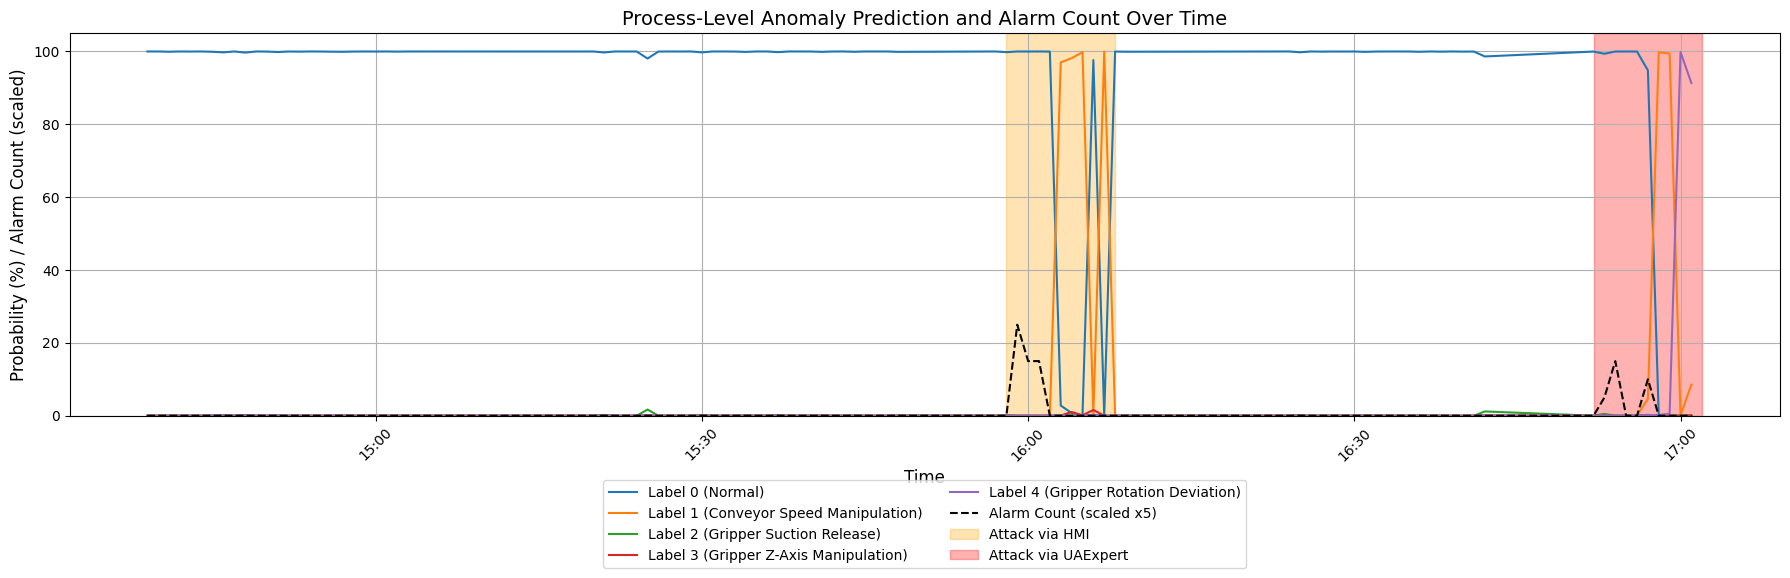

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_process['Minute'] = pd.to_datetime(df_process['Minute'])

# Descriptive label names
label_desc = {
    0: 'Label 0 (Normal)',
    1: 'Label 1 (Conveyor Speed Manipulation)',
    2: 'Label 2 (Gripper Suction Release)',
    3: 'Label 3 (Gripper Z-Axis Manipulation)',
    4: 'Label 4 (Gripper Rotation Deviation)'
}

# Plot setup
plt.figure(figsize=(18, 6))

# Plot each class probability
for i in range(5):
    plt.plot(df_process['Minute'], df_process[f'Prob_Class_{i}'] * 100,
             label=label_desc[i], linewidth=1.5)

# Plot alarm count (scaled)
plt.plot(df_process['Minute'], df_process['alarm_count'] * 5, linestyle='--', color='black',
         label='Alarm Count (scaled x5)', linewidth=1.5)

# Define attack periods
attackviaHMI_start = pd.to_datetime('2025-05-09 15:58:00')
attackviaHMI_end   = pd.to_datetime('2025-05-09 16:08:00')
attackviaUA_start  = pd.to_datetime('2025-05-09 16:52:00')
attackviaUA_end    = pd.to_datetime('2025-05-09 17:02:00')

# Highlight attack periods
plt.axvspan(attackviaHMI_start, attackviaHMI_end, color='orange', alpha=0.3, label='Attack via HMI')
plt.axvspan(attackviaUA_start, attackviaUA_end, color='red', alpha=0.3, label='Attack via UAExpert')

# Axis and formatting
plt.title("Process-Level Anomaly Prediction and Alarm Count Over Time", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Probability (%) / Alarm Count (scaled)", fontsize=12)
plt.ylim(0, 105)
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()



## Step 2: Merge and normalize

### Merging Process Data and Network Data

In [81]:
import pandas as pd

# Start time for instance 1
start_time = pd.to_datetime("2025-05-09 14:35:00").tz_localize("Europe/London")

# Generate timestamps for all instances (1 to 148)
df_network['timestamp_bst'] = pd.date_range(
    start=start_time,
    periods=len(df_network),
    freq='1min'
)

In [82]:
df_network

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,Network_Label_3Class,timestamp,timestamp_bst,node_ids_written,source_ports,message_sizes,explanation
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,Network - Normal,NaT,2025-05-09 14:35:00+01:00,NaN,NaN,NaN,NaN
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,Network - Normal,NaT,2025-05-09 14:36:00+01:00,NaN,NaN,NaN,NaN
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,Network - Normal,NaT,2025-05-09 14:37:00+01:00,NaN,NaN,NaN,NaN
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,Network - Anomaly,2025-09-05 13:38:00,2025-05-09 14:38:00+01:00,-,"53373, 53218","253, 100, 204, 189, 1584",Unusual OPC UA write pattern detected
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,Network - Anomaly,2025-09-05 13:39:00,2025-05-09 14:39:00+01:00,-,"53373, 53218","253, 100, 204, 189, 255",Unusual OPC UA write pattern detected
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,Network - Anomaly,2025-09-05 15:58:00,2025-05-09 16:58:00+01:00,"-, MCDData.GetBox_signal, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 159",Unusual OPC UA write pattern detected
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,Network - Anomaly,2025-09-05 15:59:00,2025-05-09 16:59:00+01:00,"-, MCDData.RotatePosition, MCDData.Gripper_Z_S...","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,Network - Anomaly,2025-09-05 16:00:00,2025-05-09 17:00:00+01:00,"-, MCDData.RotatePosition","53373, 52131, 53218","253, 100, 204, 189, 132",Unusual OPC UA write pattern detected
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,Network - Anomaly,2025-09-05 16:01:00,2025-05-09 17:01:00+01:00,-,"52131, 53373, 53218","85, 66, 253, 100, 204",Unusual OPC UA write pattern detected


In [83]:
df_process['Minute'] = pd.to_datetime(df_process['Minute']).dt.tz_localize("Europe/London")

In [84]:
df_fusion = df_network.merge(df_process, left_on='timestamp_bst', right_on='Minute', how='left')

In [85]:
df_fusion

,instance_x,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,unique_write_targets_count,Network_Anomaly_Score,Network_Predicted_Label,Network_Label_3Class,...,Prob_Class_4,Label_Description,alarm_count,high_priority_count,sources,float_mean,float_max,float_min,process_score,Process_Label_3Class
0,1,0,0.000000,5940,0.754382,7874,NaN,0.012531,0,Network - Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,0.000000,5780,0.753979,7666,NaN,0.012531,0,Network - Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,0,0.000000,5950,0.754406,7887,NaN,0.012531,0,Network - Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,0.000000,5960,0.751008,7936,NaN,-0.087744,1,Network - Anomaly,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,0.000000,5960,0.743142,8020,NaN,-0.139128,1,Network - Anomaly,...,0.0000,Label 0: Normal_NoIntervention,0.0,0.0,NaN,NaN,NaN,NaN,0.0000,Process - Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,144,3,0.000394,5693,0.747015,7621,2.0,-0.139128,1,Network - Anomaly,...,0.0019,Label 1: Conveyor_SpeedManipulation,0.0,0.0,NaN,NaN,NaN,NaN,0.9978,Process - Anomaly
144,145,5,0.000650,5745,0.747268,7688,2.0,-0.139128,1,Network - Anomaly,...,0.0055,Label 1: Conveyor_SpeedManipulation,0.0,0.0,NaN,NaN,NaN,NaN,0.9942,Process - Anomaly
145,146,1,0.000132,5671,0.748449,7577,1.0,-0.139128,1,Network - Anomaly,...,0.9984,Label 4: Gripper_RotationDeviation,0.0,0.0,NaN,NaN,NaN,NaN,0.9984,Process - Anomaly
146,147,0,0.000000,5710,0.750033,7613,NaN,-0.117374,1,Network - Anomaly,...,0.9135,Label 4: Gripper_RotationDeviation,0.0,0.0,NaN,NaN,NaN,NaN,0.9135,Process - Anomaly


In [86]:
df_fusion.to_csv('fusion_network_process_view.csv', index=False)

from google.colab import files
files.download('fusion_network_process_view.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

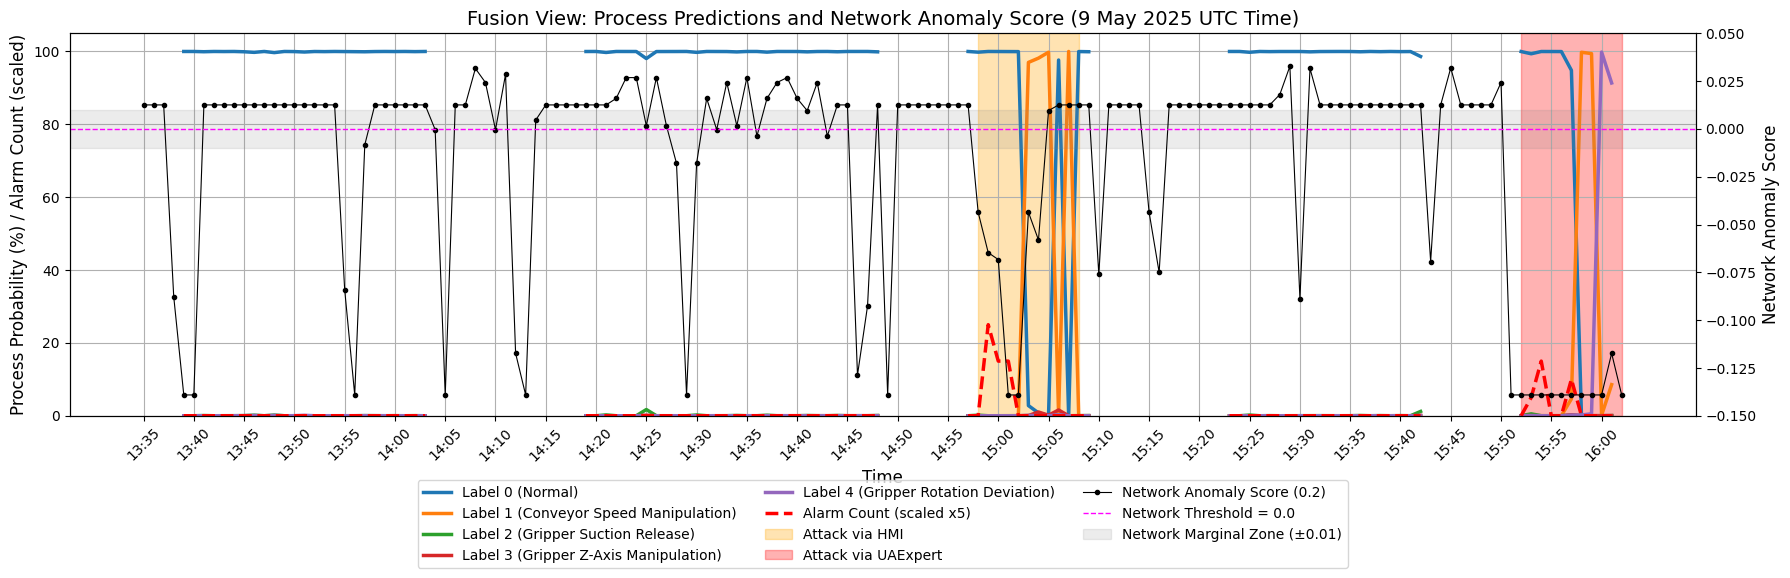

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo

tz = ZoneInfo("Europe/London")

# Ensure datetime format
df_fusion['timestamp_bst'] = pd.to_datetime(df_fusion['timestamp_bst'])

# Labels for process prediction
label_desc = {
    0: 'Label 0 (Normal)',
    1: 'Label 1 (Conveyor Speed Manipulation)',
    2: 'Label 2 (Gripper Suction Release)',
    3: 'Label 3 (Gripper Z-Axis Manipulation)',
    4: 'Label 4 (Gripper Rotation Deviation)'
}

# Set up the plot
fig, ax1 = plt.subplots(figsize=(18, 6))

# Plot process class probabilities on primary Y-axis
for i in range(5):
    ax1.plot(df_fusion['timestamp_bst'], df_fusion[f'Prob_Class_{i}'] * 100, label=label_desc[i], linewidth=2.5)

# Plot alarm count scaled
ax1.plot(df_fusion['timestamp_bst'], df_fusion['alarm_count'] * 5, linestyle='--', color='red',
         label='Alarm Count (scaled x5)', linewidth=2.5)

# Highlight attack periods
attackviaHMI_start = pd.to_datetime('2025-05-09 15:58:00').replace(tzinfo=tz)
attackviaHMI_end   = pd.to_datetime('2025-05-09 16:08:00').replace(tzinfo=tz)
attackviaUA_start  = pd.to_datetime('2025-05-09 16:52:00').replace(tzinfo=tz)
attackviaUA_end    = pd.to_datetime('2025-05-09 17:02:00').replace(tzinfo=tz)

ax1.axvspan(attackviaHMI_start, attackviaHMI_end, color='orange', alpha=0.3, label='Attack via HMI')
ax1.axvspan(attackviaUA_start, attackviaUA_end, color='red', alpha=0.3, label='Attack via UAExpert')

# Y-axis formatting
ax1.set_ylabel("Process Probability (%) / Alarm Count (scaled)", fontsize=12)
ax1.set_ylim(0, 105)
ax1.grid(True)

# X-axis formatting
ax1.set_xlabel("Time", fontsize=12)
ax1.set_xticks(df_fusion['timestamp_bst'][::5])  # fewer ticks
ax1.tick_params(axis='x', rotation=45)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Create a secondary Y-axis for network anomaly score
ax2 = ax1.twinx()
ax2.plot(df_fusion['timestamp_bst'], df_fusion['Network_Anomaly_Score'], color='black', marker='o', markersize=3,
         linestyle='-', linewidth=0.8, label='Network Anomaly Score (0.2)')
ax2.axhline(y=0.0, color='magenta', linestyle='--', linewidth=1, label='Network Threshold = 0.0')
ax2.axhspan(-0.01, 0.01, color='gray', alpha=0.15, label='Network Marginal Zone (±0.01)')
ax2.set_ylabel("Network Anomaly Score", fontsize=12)
ax2.set_ylim(-0.15, 0.05)

# Merge legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10)

# Final layout
plt.title("Fusion View: Process Predictions and Network Anomaly Score (9 May 2025 UTC Time)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Ensure both DataFrames have the same column name for merging
df_process = df_process.rename(columns={'Instance': 'instance'})
df_process['instance'] = df_process['instance'].astype(int)
df_network['instance'] = df_network['instance'].astype(int)

# Now perform the merge correctly
df_combined = pd.merge(
    df_network,              # left DataFrame
    df_process,              # right DataFrame
    on='instance',           # common column to merge on
    how='inner'              # merge type (inner keeps only matching instances)
)

# Display the result
df_combined

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.25,Network_Predicted_Label,Network_Ground_Truth,Network_Label_3Class,Process_Predicted_Label,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Process_Ground_Truth,Label_Description,process_score,Process_Label_3Class
0,1,0,0.000000,584,0.234256,2493,0.115396,0,0,Network - Normal,0,0.9999,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
1,2,0,0.000000,514,0.233424,2202,-0.076033,1,0,Network - Anomaly,0,0.9999,0.0000,0.0001,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0001,Process - Normal
2,3,0,0.000000,583,0.234231,2489,0.146823,0,0,Network - Normal,0,0.9998,0.0000,0.0001,0.0000,0.0001,0,Label 0: Normal_NoIntervention,0.0001,Process - Normal
3,4,0,0.000000,572,0.234234,2442,0.148887,0,0,Network - Normal,2,0.0061,0.0003,0.9923,0.0002,0.0011,0,Label 0: Normal_NoIntervention,0.9923,Process - Anomaly
4,5,0,0.000000,540,0.234070,2307,0.152311,0,0,Network - Normal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
5,6,0,0.000000,590,0.234406,2517,-0.007075,1,0,Network - Marginal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
6,7,0,0.000000,569,0.233868,2433,0.021224,0,0,Network - Marginal,0,0.9999,0.0000,0.0001,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0001,Process - Normal
7,8,0,0.000000,584,0.234068,2495,0.154344,0,0,Network - Normal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal
8,9,0,0.000000,576,0.230124,2503,-0.282645,1,0,Network - Anomaly,0,0.9996,0.0000,0.0002,0.0000,0.0001,0,Label 0: Normal_NoIntervention,0.0002,Process - Normal
9,10,0,0.000000,576,0.234051,2461,0.128183,0,0,Network - Normal,0,1.0000,0.0000,0.0000,0.0000,0.0000,0,Label 0: Normal_NoIntervention,0.0000,Process - Normal


In [ ]:
df_combined.to_csv('combined_network_process_view.csv', index=False)

from google.colab import files
files.download('combined_network_process_view.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 3: Handling of Contradiction Decisons from Different Model (Confidence-Aware Logic)

**Why decision fusion?**

From the analysis above, the marginal cases include

1.   Network Marginal Instances: [6, 7, 11, 21, 28, 32, 33, 39]
2.   Process Marginal Instances: [46, 52, 56, 58, 60]

The purpose of the decision fusion is to handle the marginal instances. If the overall result align (i.e., network score and process score indicate normal), we use the label of process score for explainability. If the overall result contradict (i.e., network score says normal, process score says threat, we compare the absolute value of the two score to see who has higher score.


**Logic behind:**

A process model that gives multiclass predictions: Label 0 - 4 (Normal, then types of attack).

A network score from Isolation Forest, where:

*   network_score > 0: Normal
*   network_score < 0: Anomalous

But network_score does not tell us which type of attack.

If process confidence is low (process score is less than 0.8), and network score is anomalous (and wins by absolute confidence), then pick the most likely attack class from the process model — since network model does not distinguish attack types. This retains the fine-grained attack classification from process model.

In [ ]:
!pip install graphviz

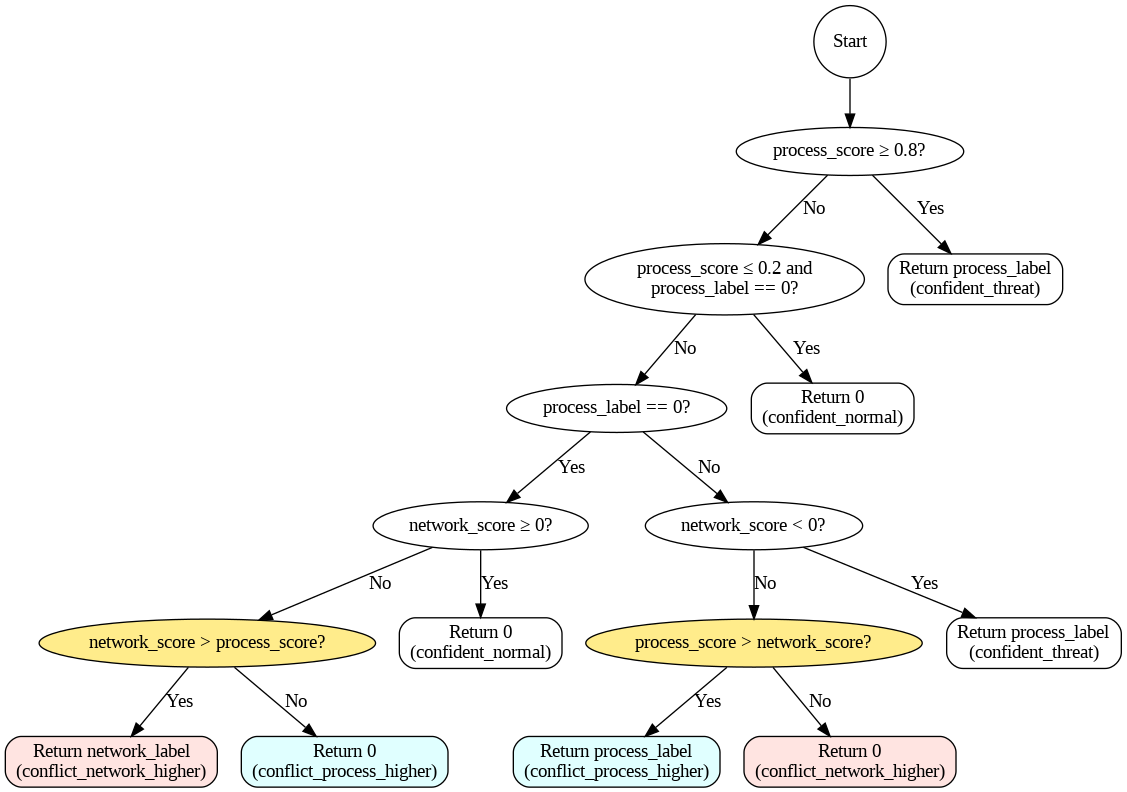

In [ ]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph(comment='Rule-based Confidence-Aware Decision Fusion')

# Styles for special cases
marginal_style = {'style': 'filled', 'fillcolor': 'lightgoldenrod1'}

# Decision Nodes
dot.node('A', 'Start', shape='circle')
dot.node('B', 'process_score ≥ 0.8?', shape='ellipse')
dot.node('D', 'process_score ≤ 0.2 and\nprocess_label == 0?', shape='ellipse')
dot.node('F', 'process_label == 0?', shape='ellipse')
dot.node('G', 'network_score ≥ 0?', shape='ellipse')
dot.node('I', 'network_score > process_score?', shape='ellipse', **marginal_style)
dot.node('L', 'network_score < 0?', shape='ellipse')
dot.node('N', 'process_score > network_score?', shape='ellipse', **marginal_style)

# Leaf/Output Nodes
dot.node('C', 'Return process_label\n(confident_threat)', shape='box', style='rounded')
dot.node('E', 'Return 0\n(confident_normal)', shape='box', style='rounded')
dot.node('H', 'Return 0\n(confident_normal)', shape='box', style='rounded')
dot.node('J', 'Return network_label\n(conflict_network_higher)', shape='box', style='rounded,filled', fillcolor='mistyrose')
dot.node('K', 'Return 0\n(conflict_process_higher)', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('O', 'Return process_label\n(conflict_process_higher)', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('P', 'Return 0\n(conflict_network_higher)', shape='box', style='rounded,filled', fillcolor='mistyrose')
dot.node('M', 'Return process_label\n(confident_threat)', shape='box', style='rounded')

# Arrows / Decision Paths
dot.edge('A', 'B')
dot.edge('B', 'C', 'Yes')
dot.edge('B', 'D', 'No')
dot.edge('D', 'E', 'Yes')
dot.edge('D', 'F', 'No')
dot.edge('F', 'G', 'Yes')
dot.edge('G', 'H', 'Yes')
dot.edge('G', 'I', 'No')
dot.edge('I', 'J', 'Yes')
dot.edge('I', 'K', 'No')
dot.edge('F', 'L', 'No')
dot.edge('L', 'M', 'Yes')
dot.edge('L', 'N', 'No')
dot.edge('N', 'O', 'Yes')
dot.edge('N', 'P', 'No')

# Save and display
dot.render('fusion_confidence_tree_marginal', format='png', cleanup=True)
Image(filename='fusion_confidence_tree_marginal.png')

In [ ]:
def resolve_final_label_with_reason(row):
    process_score = row['process_score']  # 0.0 to 1.0
    network_score = row['anomaly_score_0.25']  # +ve = Normal, -ve = Anomaly
    process_label = row['Process_Predicted_Label']  # 0 = Normal, 1–4 = Attack class

    try:
        attack_classes = ['Prob_Class_1', 'Prob_Class_2', 'Prob_Class_3', 'Prob_Class_4']
        attack_scores = row[attack_classes].astype(float)
    except Exception as e:
        return pd.Series([process_label, 'error_attack_score'])

    # Step 1: Convert network anomaly score into a label
    if network_score >= 0:
        network_label = 0
    else:
        best_attack_class = attack_scores.idxmax()
        network_label = int(best_attack_class.split('_')[-1])

    # Step 2: High confidence regions for process (trust process label directly)
    if process_score >= 0.8:
        return pd.Series([process_label, 'confident_threat'])

    if process_score <= 0.2 and process_label == 0:
        return pd.Series([0, 'confident_normal'])

    # Step 3: Marginal region for process (0.2 < score < 0.8)
    if process_label == 0: # process predicts normal
        if network_score >= 0: # network predicts normal
            return pd.Series([0, 'confident_normal'])
        else:
            final_label = network_label if abs(network_score) > process_score else 0
            return pd.Series([
                final_label,
                'conflict_network_higher' if abs(network_score) > process_score else 'conflict_process_higher'
            ])
    else: # process predicts threat
        if network_score < 0: # network predicts threat
            return pd.Series([process_label, 'confident_threat'])
        else:
            final_label = process_label if process_score > abs(network_score) else 0
            return pd.Series([
                final_label,
                'conflict_process_higher' if process_score >= abs(network_score) else 'conflict_network_higher'
            ])

In [ ]:
df_combined[['final_fused_label', 'decision_reason']] = df_combined.apply(resolve_final_label_with_reason, axis=1)

In [ ]:
# Evaluate against Ground Truth (fused_pred binary: 0 = normal, 1 = attack or anomaly)
df_combined[['instance', 'process_score', 'anomaly_score_0.25', 'Process_Predicted_Label', 'Network_Predicted_Label', 'final_fused_label' ,'Process_Ground_Truth', 'decision_reason']]

,instance,process_score,anomaly_score_0.25,Process_Predicted_Label,Network_Predicted_Label,final_fused_label,Process_Ground_Truth,decision_reason
0,1,0.0000,0.115396,0,0,0,0,confident_normal
1,2,0.0001,-0.076033,0,1,0,0,confident_normal
2,3,0.0001,0.146823,0,0,0,0,confident_normal
3,4,0.9923,0.148887,2,0,2,0,confident_threat
4,5,0.0000,0.152311,0,0,0,0,confident_normal
5,6,0.0000,-0.007075,0,1,0,0,confident_normal
6,7,0.0001,0.021224,0,0,0,0,confident_normal
7,8,0.0000,0.154344,0,0,0,0,confident_normal
8,9,0.0002,-0.282645,0,1,0,0,confident_normal
9,10,0.0000,0.128183,0,0,0,0,confident_normal


In [ ]:
# Get the count dictionary
reasons = df_combined['decision_reason'].value_counts().to_dict()

# Extract counts safely (default to 0 if key is missing)
n_confident_threat = reasons.get('confident_threat', 0)
n_confident_normal = reasons.get('confident_normal', 0)
n_conflict_process_higher = reasons.get('conflict_process_higher', 0)
n_conflict_network_higher = reasons.get('conflict_network_higher', 0)
n_error = reasons.get('error_attack_score', 0)  # Optional, in case you want to track errors

# Print all values (optional, for debugging)
print("confident_threat:", n_confident_threat)
print("confident_normal:", n_confident_normal)
print("conflict_process_higher:", n_conflict_process_higher)
print("conflict_network_higher:", n_conflict_network_higher)

confident_threat: 49
confident_normal: 9
conflict_process_higher: 1
conflict_network_higher: 1


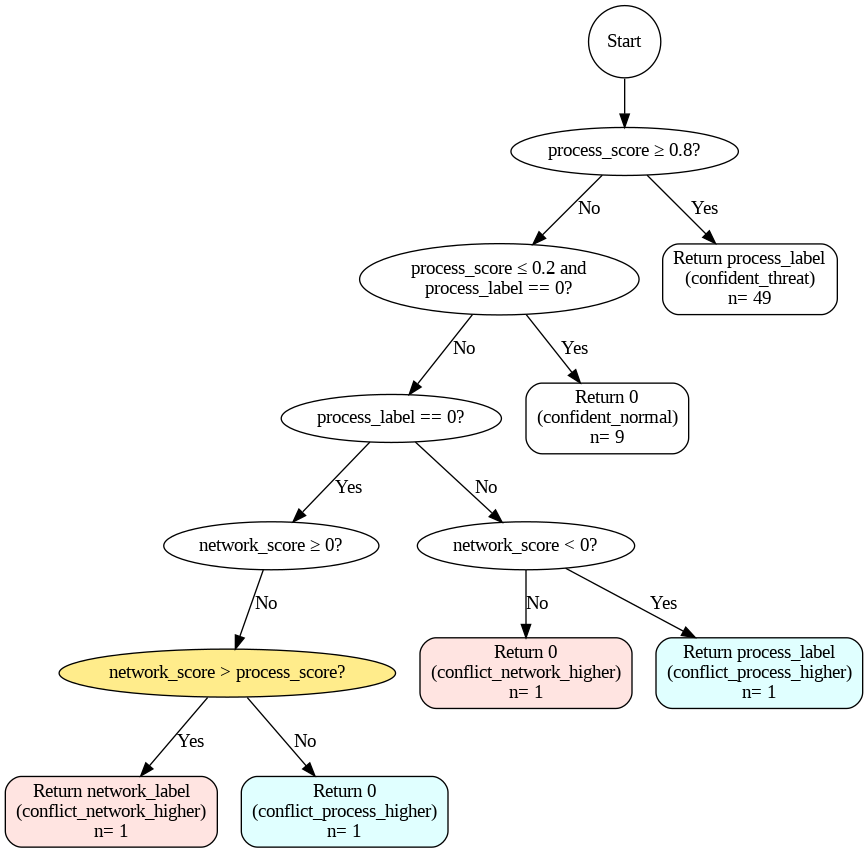

In [ ]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph(comment='Rule-based Confidence-Aware Decision Fusion')

# Styles for special cases
marginal_style = {'style': 'filled', 'fillcolor': 'lightgoldenrod1'}

# Decision Nodes
dot.node('A', 'Start', shape='circle')
dot.node('B', 'process_score ≥ 0.8?', shape='ellipse')
dot.node('D', 'process_score ≤ 0.2 and\nprocess_label == 0?', shape='ellipse')
dot.node('F', 'process_label == 0?', shape='ellipse')
dot.node('G', 'network_score ≥ 0?', shape='ellipse')
dot.node('I', 'network_score > process_score?', shape='ellipse', **marginal_style)
dot.node('L', 'network_score < 0?', shape='ellipse')
dot.node('N', 'process_score > network_score?', shape='ellipse', **marginal_style)

# Leaf/Output Nodes
dot.node('C', f'Return process_label\n(confident_threat)\nn= {reasons.get("confident_threat", 0)}', shape='box', style='rounded')
dot.node('E', f'Return 0\n(confident_normal)\nn= {reasons.get("confident_normal", 0)}', shape='box', style='rounded')
dot.node('J', f'Return network_label\n(conflict_network_higher)\nn= {reasons.get("conflict_network_higher", 0)}', shape='box', style='rounded,filled', fillcolor='mistyrose')
dot.node('K', f'Return 0\n(conflict_process_higher)\nn= {reasons.get("conflict_process_higher", 0)}', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('M', f'Return process_label\n(conflict_process_higher)\nn= {reasons.get("conflict_process_higher", 0)}', shape='box', style='rounded,filled', fillcolor='lightcyan')
dot.node('N', f'Return 0\n(conflict_network_higher)\nn= {reasons.get("conflict_network_higher", 0)}', shape='box', style='rounded,filled', fillcolor='mistyrose')

output_styles = {
    'confident_threat': {'style': 'rounded'},
    'confident_normal': {'style': 'rounded'},
    'conflict_network_higher': {'style': 'rounded,filled', 'fillcolor': 'mistyrose'},
    'conflict_process_higher': {'style': 'rounded,filled', 'fillcolor': 'lightcyan'},
}

# Arrows / Decision Paths
dot.edge('A', 'B')
dot.edge('B', 'C', 'Yes')
dot.edge('B', 'D', 'No')
dot.edge('D', 'E', 'Yes')
dot.edge('D', 'F', 'No')
dot.edge('F', 'G', 'Yes')
dot.edge('G', 'I', 'No')
dot.edge('I', 'J', 'Yes')
dot.edge('I', 'K', 'No')
dot.edge('F', 'L', 'No')
dot.edge('L', 'M', 'Yes')
dot.edge('L', 'N', 'No')



# Save and display
dot.render('fusion_confidence_tree_marginal', format='png', cleanup=True)
Image(filename='fusion_confidence_tree_marginal.png')

In [ ]:
from google.colab import files

# Save the merged + fused results
df_combined.to_csv("fused_results_60_instances.csv", index=False)

# Trigger download to local machine
files.download("fused_results_60_instances.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

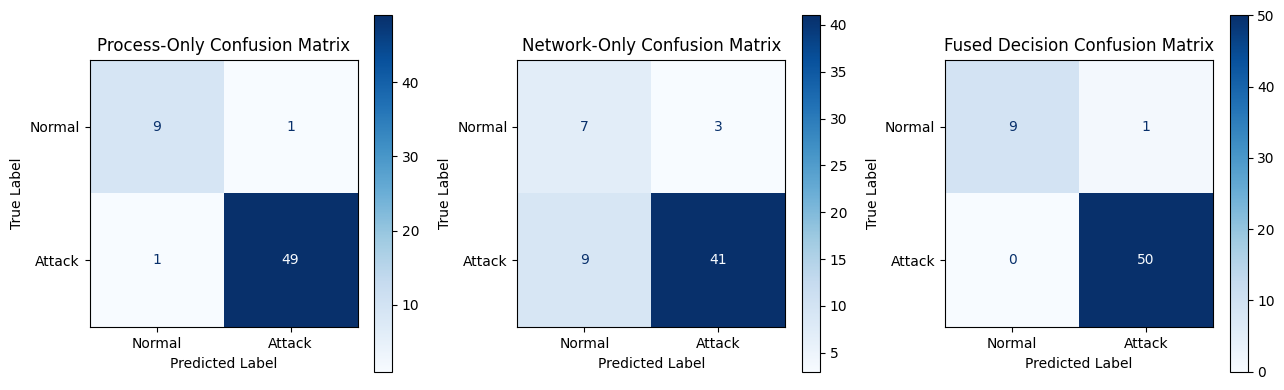

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define binary ground truth: 0 = normal, 1 = attack (any label other than 0)
df_combined['true_binary'] = df_combined['Process_Ground_Truth'].apply(lambda x: 0 if x == 0 else 1)

# Binary predictions for each method
df_combined['process_binary'] = df_combined['Process_Predicted_Label'].apply(lambda x: 0 if x == 0 else 1)
df_combined['network_binary'] = df_combined['Network_Predicted_Label'].apply(lambda x: 0 if x == 0 else 1)
df_combined['fused_binary'] = df_combined['final_fused_label'].apply(lambda x: 0 if x == 0 else 1)

# Compute confusion matrices
cm_process = confusion_matrix(df_combined['true_binary'], df_combined['process_binary'])
cm_network = confusion_matrix(df_combined['true_binary'], df_combined['network_binary'])
cm_fused   = confusion_matrix(df_combined['true_binary'], df_combined['fused_binary'])

# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ['Process-Only', 'Network-Only', 'Fused Decision']
cms = [cm_process, cm_network, cm_fused]

for ax, cm, title in zip(axes, cms, titles):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(ax=ax, values_format='d', cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

**Fusion logic corrected predictions originally misclassified by the process model alone — specifically by leveraging network anomaly scores.**

In [ ]:
from sklearn.metrics import classification_report

print("Process-Only Report:\n", classification_report(df_combined['true_binary'], df_combined['process_binary']))
print("Network-Only Report:\n", classification_report(df_combined['true_binary'], df_combined['network_binary']))
print("Fused Decision Report:\n", classification_report(df_combined['true_binary'], df_combined['fused_binary']))

Process-Only Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.98      0.98      0.98        50

    accuracy                           0.97        60
   macro avg       0.94      0.94      0.94        60
weighted avg       0.97      0.97      0.97        60

Network-Only Report:
               precision    recall  f1-score   support

           0       0.44      0.70      0.54        10
           1       0.93      0.82      0.87        50

    accuracy                           0.80        60
   macro avg       0.68      0.76      0.71        60
weighted avg       0.85      0.80      0.82        60

Fused Decision Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.98      1.00      0.99        50

    accuracy                           0.98        60
   macro avg       0.99      0.95      0.97        60
weight

## Step 4: Reporting

The dashboard is to be adjusted for instances over time, where x-axis will be the timeline.

In [ ]:
reason_map = {
    'confident_threat': 'High confidence — Threat detected',
    'confident_normal': 'High confidence — Normal behavior',
    'conflict_process_higher': 'Disagreement — Process more confident',
    'conflict_network_higher': 'Disagreement — Network more confident',
    'error_attack_score': 'Error extracting process class scores',
}

df_combined['reason_description'] = df_combined['decision_reason'].map(reason_map)

In [ ]:
display(df_combined[['instance', 'final_fused_label', 'reason_description']])

,instance,final_fused_label,reason_description
0,1,0,High confidence — Normal behavior
1,2,0,High confidence — Normal behavior
2,3,0,High confidence — Normal behavior
3,4,2,High confidence — Threat detected
4,5,0,High confidence — Normal behavior
5,6,0,High confidence — Normal behavior
6,7,0,High confidence — Normal behavior
7,8,0,High confidence — Normal behavior
8,9,0,High confidence — Normal behavior
9,10,0,High confidence — Normal behavior


In [ ]:
import plotly.express as px

fig = px.scatter(
    df_combined,
    x='instance',
    y='process_score',
    color='decision_reason',
    hover_data=['final_fused_label', 'reason_description'],
    title='Process Confidence with Fusion Reason'
)
fig.show()

# 2nd Level Decision Fusion - IT / OT Fusion

## Step 1: Loading the list of host anomalies and fused OT anomalies

##Step 2: Merge and normalize

## Step 3: Reporting